In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, when, avg, expr, log1p, expm1, abs, lit,desc
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, OneHotEncoder,FeatureHasher
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor
from pyspark.ml.regression import RandomForestRegressionModel, LinearRegressionModel, GBTRegressionModel
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder, TrainValidationSplit
from pyspark.sql.types import FloatType, IntegerType
import matplotlib.pyplot as plt
import os
# from dotenv import load_dotenv


In [2]:
spark=SparkSession.builder.appName('Inspecting_healthcare').getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/24 18:35:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
spark.sparkContext.setLogLevel("ERROR")

In [4]:
#This is much faster than uploading the file. Program written by professor and edited by student.
from downloaderCHPC import ensure_dataset
ensure_dataset()

Extracting CSVs into /uufs/chpc.utah.edu/common/home/u1542688/Project/dataSets/final_data ...
Done. CSVs are in: /uufs/chpc.utah.edu/common/home/u1542688/Project/dataSets/final_data


PosixPath('/uufs/chpc.utah.edu/common/home/u1542688/Project/dataSets/final_data')

In [5]:
# load_dotenv()
#Create the folder with the csv files and store it in your preferred locaton in your PC. Do not push the csv files on github LOL.

# base_path=os.getenv('FOLDER_PATH')
base_path='dataSets/final_data'

url=base_path+"/final_data.csv" 
data=spark.read.option('header','true').option('inferSchema','true').csv(url)

In [6]:
data.show()

+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc|Tot_Rndrng_Prvdrs|Tot_Benes|Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Year|
+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+
|                  1|   00100|             N|            F|              239|      219|    322.0|               322|  1069.9324224|2013|
|                  1|   00103|             N|            F|              515|     2394|   4206.0|              4206|  610.75801474|2013|
|                  1|   00104|             N|            F|              286|      309|   3103.0|              3103|  396.53074444|2013|
|                  1|   00120|             N|            F|              363|      615|    986.0|               985|  711.17103448|2013|
|                  1|   00124|           

In [7]:
data.printSchema()

#checking...
before_dropping=data.count()
data=data.na.drop()
after_dropping=data.count()

print('Dropped rows with null values',before_dropping-after_dropping)

root
 |-- Rndrng_Prvdr_Geo_Cd: integer (nullable = true)
 |-- HCPCS_Cd: string (nullable = true)
 |-- HCPCS_Drug_Ind: string (nullable = true)
 |-- Place_Of_Srvc: string (nullable = true)
 |-- Tot_Rndrng_Prvdrs: integer (nullable = true)
 |-- Tot_Benes: integer (nullable = true)
 |-- Tot_Srvcs: double (nullable = true)
 |-- Tot_Bene_Day_Srvcs: integer (nullable = true)
 |-- Avg_Sbmtd_Chrg: double (nullable = true)
 |-- Year: integer (nullable = true)



Dropped rows with null values 0


In [8]:
#Defining Columns
total_cat=['HCPCS_Cd', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Rndrng_Prvdr_Geo_Cd', 'Year']
num_cols=['Tot_Rndrng_Prvdrs','Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs']
low_cardy=[]
high_cardy=[]

for column in total_cat:
    
    data=data.withColumn(column,col(column).cast('string')) #casting to treat as category 

    dis_val=data.select(column).distinct().count()

    if dis_val<60:
        low_cardy.append(column)
    else:
        high_cardy.append(column)

    print(f'Column: {column} number of unique values: {dis_val}')

print(f'\nLow cardinality columns: {low_cardy}')
print(f'High cardinality columns: {high_cardy}')

Column: HCPCS_Cd number of unique values: 9966


Column: HCPCS_Drug_Ind number of unique values: 2


Column: Place_Of_Srvc number of unique values: 2


Column: Rndrng_Prvdr_Geo_Cd number of unique values: 56


Column: Year number of unique values: 11

Low cardinality columns: ['HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Rndrng_Prvdr_Geo_Cd', 'Year']
High cardinality columns: ['HCPCS_Cd']


Data Exploration on HCPCS_Cd

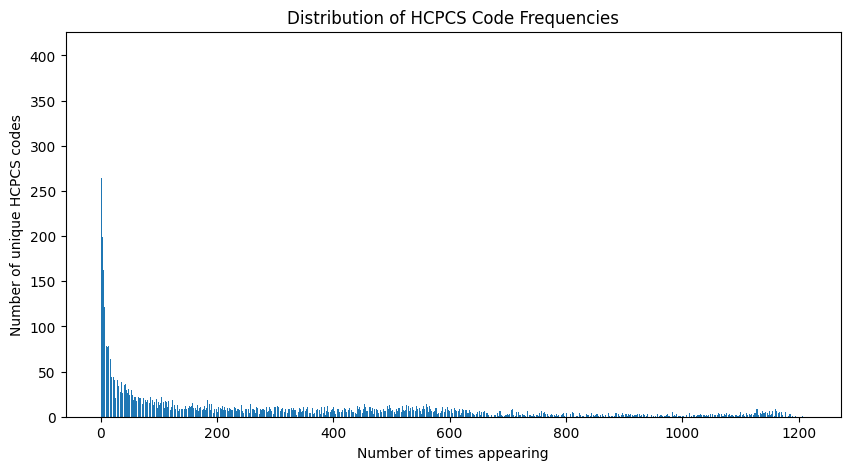

In [9]:
unique_count = data.groupBy("HCPCS_Cd").count()

groupCount = (
    unique_count
    .groupBy("count")
    .agg(count("*").alias("num_codes"))
    .orderBy("count")
)

pdf = groupCount.toPandas()

plt.figure(figsize=(10,5))
plt.bar(pdf["count"], pdf["num_codes"])
plt.xlabel("Number of times appearing")
plt.ylabel("Number of unique HCPCS codes")
plt.title("Distribution of HCPCS Code Frequencies")
plt.show()

# groupCount.show()

Based on the last graphic, anything under 50 ocurrences are rare

In [10]:
before_filter = unique_count.count()

common_codes = (
    unique_count
    .filter(col("count") > 50)
    .select("HCPCS_Cd")
)

common_rows = (
    data.join(common_codes, on="HCPCS_Cd", how="left_semi")
)

rare_rows = (
    data.join(common_codes, on="HCPCS_Cd", how="left_anti")
        .withColumn("HCPCS_Cd", lit("RARE").cast("string"))
)

# force identical schema/order on both sides
common_rows = common_rows.select(*data.columns)
rare_rows = rare_rows.select(*data.columns)

data = common_rows.unionByName(rare_rows)

unique_count = data.groupBy("HCPCS_Cd").count()
after_filter = unique_count.count()

print(f"Data set before filtering count: {before_filter}")
print(f"Data set after filtering count: {after_filter}")

Data set before filtering count: 9966
Data set after filtering count: 6568


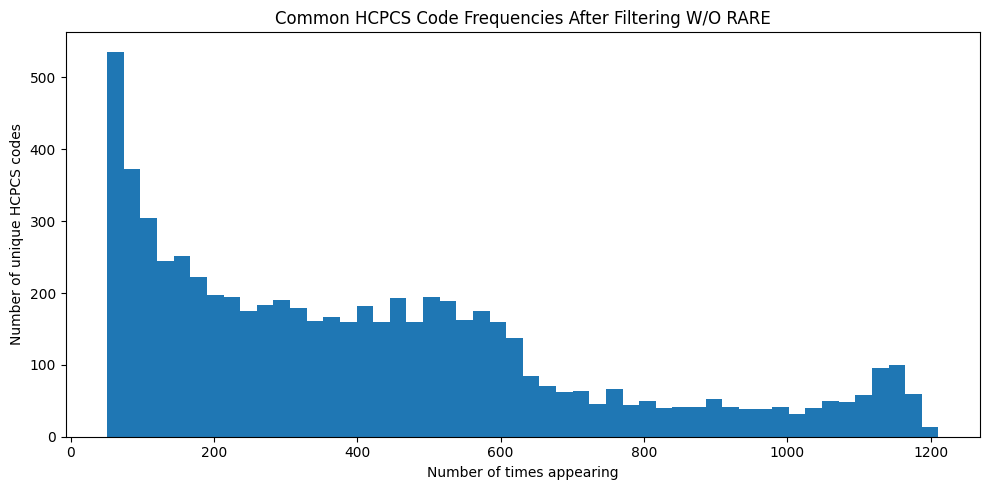

RARE bucket size: 51302


In [11]:

common_after = data.filter(col("HCPCS_Cd") != "RARE") \
                   .groupBy("HCPCS_Cd").count()

rare_count = data.filter(col("HCPCS_Cd") == "RARE").count()

freq_common = common_after.select("count").toPandas()["count"]

plt.figure(figsize=(10, 5))
plt.hist(freq_common, bins=50)
plt.title("Common HCPCS Code Frequencies After Filtering W/O RARE")
plt.xlabel("Number of times appearing")
plt.ylabel("Number of unique HCPCS codes")
plt.tight_layout()
plt.show()

print("RARE bucket size:", rare_count)

Preprocessing

In [12]:
# X=data.select('*')
#adjust percentage based on your hardware
X=data.sample(fraction=0.05,seed=42)

for column in num_cols:
    X=X.withColumn(column,log1p(col(column)))

#Now the target
X=X.withColumn('Avg_Sbmtd_Chrg',log1p(col('Avg_Sbmtd_Chrg')))

X_train,X_test=X.randomSplit([0.8, 0.2], seed=42)

print("Train:", X_train.count())
print("Test:", X_test.count())

Train: 112031


Test: 28146


Pipeline Construction

In [13]:
# #Defining Columns
# total_cat=['HCPCS_Cd', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Rndrng_Prvdr_Geo_Cd', 'Year']
# num_cols=['Tot_Rndrng_Prvdrs','Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs']
# low_cardy=[]
# high_cardy=[]

# Low cardinality columns: ['HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Rndrng_Prvdr_Geo_Cd', 'Year']
# High cardinality columns: ['HCPCS_Cd']

#indexing
string_indexer=StringIndexer(inputCols=total_cat[1:],
                             outputCols=[f'{c}_idx' for c in total_cat[1:]],#skipping HCPCS_Cd
                             handleInvalid='keep')

ohencoder=OneHotEncoder(inputCols=[f'{c}_idx' for c in low_cardy],
                        outputCols=[f'{c}_ohe' for c in low_cardy],
                        handleInvalid='keep'
)


# Hash HCPCS_Cd into a fixed-size vector
hcpcs_hasher = FeatureHasher(
    inputCols=["HCPCS_Cd"],
    outputCol='HCPCS_Cd_hash',
    numFeatures=1024
)
#6.4 categories per bucket, not bad

#vectorize to scale
scale_assembler=VectorAssembler(inputCols=num_cols,
                                outputCol='num_features')

#scaling #check if log transfor need to be used for the other columns not just the target!!!!!
scaler=StandardScaler(inputCol='num_features',
                      outputCol='scaled_num_features')
#vectorizing everything
assembler=VectorAssembler(
    inputCols=['HCPCS_Cd_hash']+
    [f'{c}_ohe' for c in low_cardy]+
    ['scaled_num_features'],
 outputCol='Features_Col'
)

feature_pipeline = Pipeline(stages=[
    string_indexer,
    ohencoder,
    hcpcs_hasher,
    scale_assembler,
    scaler,
    assembler
])

feature_model = feature_pipeline.fit(X_train)

train_features = feature_model.transform(X_train).cache()
test_features  = feature_model.transform(X_test).cache()

train_features.count()

112031

In [14]:
# Run this on CHPC. it helps to know if we can do paralellism with Cross validation
sc = spark.sparkContext

print("Default parallelism:", sc.defaultParallelism)
print("Executor memory:", sc._conf.get("spark.executor.memory"))
print("Executor cores:", sc._conf.get("spark.executor.cores"))
print("Number of executors:", sc._conf.get("spark.executor.instances"))

Default parallelism: 2
Executor memory: None
Executor cores: None
Number of executors: None


Evaluators

In [15]:
evaluator_rmse=RegressionEvaluator(labelCol='Avg_Sbmtd_Chrg',
                              predictionCol='prediction_original',
                              metricName='rmse')

evaluator_mae=RegressionEvaluator(labelCol='Avg_Sbmtd_Chrg',
                              predictionCol='prediction_original',
                              metricName='mae')

evaluator_mse=RegressionEvaluator(labelCol='Avg_Sbmtd_Chrg',
                              predictionCol='prediction_original',
                              metricName='mse')

#R2 is not helpful
# evaluator_r2=RegressionEvaluator(labelCol='Avg_Sbmtd_Chrg',
#                               predictionCol='prediction',
#                               metricName='r2')

In [16]:
#I do not want to train the same model twice or more

MODEL_MAP = {
    "RandomForestRegressor": RandomForestRegressionModel,
    "LinearRegression": LinearRegressionModel,
    "GBTRegressor": GBTRegressionModel
}

def spark_model_faster(model, X_train, X_test, model_path):
    model_name = model.__class__.__name__ #very useful to get the model name

    if os.path.exists(model_path):
        print("Loading existing model...")

        if model_name not in MODEL_MAP:
            raise ValueError(f"No loader defined for {model_name}")

        model_class = MODEL_MAP[model_name]
        fitted_model = model_class.load(model_path)

    else:
        print("Training model...")
        fitted_model = model.fit(X_train)
        fitted_model.write().overwrite().save(model_path)

    # Predict
    test_predictions = fitted_model.transform(X_test)

    # Evaluate
    # test_rmse = evaluator.evaluate(test_predictions)

    return fitted_model, test_predictions

Linear Regression

In [ ]:
lr=LinearRegression(featuresCol='Features_Col',
                    labelCol='Avg_Sbmtd_Chrg',
                    maxIter=50,
                    regParam=0.1,
                    elasticNetParam=0.5)

# lr_grid = ParamGridBuilder() \
#         .addGrid(lr.regParam, [0.01, 0.1]) \
#         .addGrid(lr.elasticNetParam, [0.5, 1.0]) \
#         .build()

lr_model,lr_preds=spark_model_faster(lr,train_features,test_features,"models/lr_model")

lr_preds = lr_preds.withColumn("prediction_original",expm1("prediction")
)

test_rmse = evaluator_rmse.evaluate(lr_preds)
test_mae = evaluator_mae.evaluate(lr_preds)
test_mse = evaluator_mse.evaluate(lr_preds)
# test_r2 = evaluator_r2.evaluate(lr_preds)


print('Showing errors for Linear Regression:')
print(f'rmse: {test_rmse}')
print(f'mae: {test_mae}')
print(f'mse: {test_mse}')
# print(f'r2: {test_r2}')

Loading existing model...
Showing errors for Linear Regression:
rmse: 628.5227733237457
mae: 528.0530970147645
mse: 395040.8765865727
r2: -149187.70083758843


Random Forest

In [ ]:
rf = RandomForestRegressor(featuresCol="Features_Col", labelCol="Avg_Sbmtd_Chrg")

# rf_grid = (
#     ParamGridBuilder()
#     .addGrid(rf.numTrees, [20, 50])
#     .addGrid(rf.maxDepth, [4, 6])
#     .build()
# )
rf_model,rf_preds=spark_model_faster(rf,train_features,test_features,"models/rf_model")

rf_preds = rf_preds.withColumn("prediction_original",expm1("prediction")
)

test_rmse = evaluator_rmse.evaluate(rf_preds)
test_mae = evaluator_mae.evaluate(rf_preds)
test_mse = evaluator_mse.evaluate(rf_preds)
# test_r2 = evaluator_r2.evaluate(rf_preds)


print('Showing errors for Random Forest:')
print(f'rmse: {test_rmse}')
print(f'mae: {test_mae}')
print(f'mse: {test_mse}')
# print(f'r2: {test_r2}')

Training model...


Showing errors for Random Forest:
rmse: 682.2524632130112
mae: 553.8593732103307
mse: 465468.4235602213
r2: -175784.9338301957


In [ ]:
gbt = GBTRegressor(
    featuresCol="Features_Col",
    labelCol="Avg_Sbmtd_Chrg",
    seed=42,
     maxIter=20,
     maxDepth=5,
     stepSize=0.1,subsamplingRate=0.8
)

# gbt_grid = (
#     ParamGridBuilder()
#     .addGrid(gbt.maxIter, [20, 40])
#     .addGrid(gbt.maxDepth, [3, 5])
#     .addGrid(gbt.stepSize, [0.05, 0.1])
#     .build()
# )

gbt_model, gbt_preds = spark_model_faster(gbt, train_features, test_features,'models/gbt_model')

gbt_preds = gbt_preds.withColumn("prediction_original",expm1("prediction")
)

test_rmse = evaluator_rmse.evaluate(gbt_preds)
test_mae = evaluator_mae.evaluate(gbt_preds)
test_mse = evaluator_mse.evaluate(gbt_preds)
# test_r2 = evaluator_r2.evaluate(gbt_preds)


print('Showing errors for GBT Regressor:')
print(f'rmse: {test_rmse}')
print(f'mae: {test_mae}')
print(f'mse: {test_mse}')
# print(f'r2: {test_r2}')

Training model...


Showing errors for GBT Regressor:
rmse: 836.2344997761139
mae: 607.9450854568679
mse: 699288.1386158073
r2: -264087.84521692


Prediction on a specific point (row)

In [75]:
#change the in_points according to the interested values

in_points=[1,'00100','N','F',239,219,322.0,322,'This is going to be predicted',2013]

#Processing for just one row starts here
req_columns=data.columns
single_point = spark.createDataFrame([in_points], req_columns)
for column in num_cols:
    single_point=single_point.withColumn(column,log1p(col(column)))
    
common_list = [row["HCPCS_Cd"] for row in common_codes.collect()]

single_point = single_point.withColumn(
    "HCPCS_Cd",
    when(col("HCPCS_Cd").isin(common_list), col("HCPCS_Cd"))
    .otherwise(lit("RARE"))
)

test_single = feature_model.transform(single_point)
test_single.count()

#using lr model for instance
pred_single = lr_model.transform(test_single)  #This can be change to another model
pred_single = pred_single.withColumn("prediction_original",expm1("prediction")
)
avg_sub=pred_single.select('prediction_original').collect()[0][0]

#Processing for just one row ends here

print(f'The prediction for the average submitted charge is: {avg_sub}')

The prediction for the average submitted charge is: 826.4149655175595


Extra Stuff

In [20]:
lr_preds.columns

['Rndrng_Prvdr_Geo_Cd',
 'HCPCS_Cd',
 'HCPCS_Drug_Ind',
 'Place_Of_Srvc',
 'Tot_Rndrng_Prvdrs',
 'Tot_Benes',
 'Tot_Srvcs',
 'Tot_Bene_Day_Srvcs',
 'Avg_Sbmtd_Chrg',
 'Year',
 'HCPCS_Drug_Ind_idx',
 'Place_Of_Srvc_idx',
 'Rndrng_Prvdr_Geo_Cd_idx',
 'Year_idx',
 'HCPCS_Drug_Ind_ohe',
 'Place_Of_Srvc_ohe',
 'Rndrng_Prvdr_Geo_Cd_ohe',
 'Year_ohe',
 'HCPCS_Cd_hash',
 'num_features',
 'scaled_num_features',
 'Features_Col',
 'prediction',
 'prediction_original']

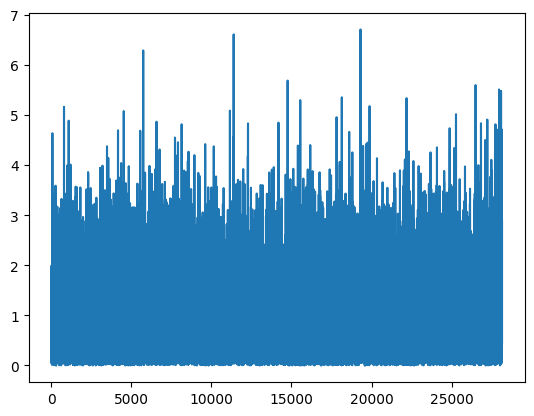

In [21]:
lr_preds=lr_preds.withColumn('Residuals',abs(col('Avg_Sbmtd_Chrg')-col('prediction')))
residuals=lr_preds.select('Residuals').toPandas()

plt.plot(range(len(residuals)),residuals)

array([[<Axes: title={'center': 'Avg_Sbmtd_Chrg'}>]], dtype=object)

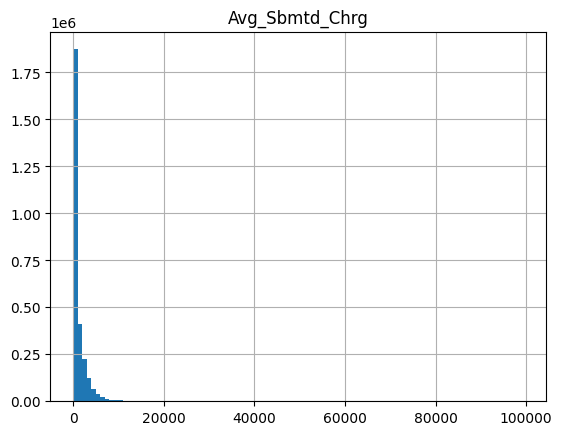

In [22]:
data.select("Avg_Sbmtd_Chrg").toPandas().hist(bins=100)

array([[<Axes: title={'center': 'Avg_Sbmtd_Chrg'}>]], dtype=object)

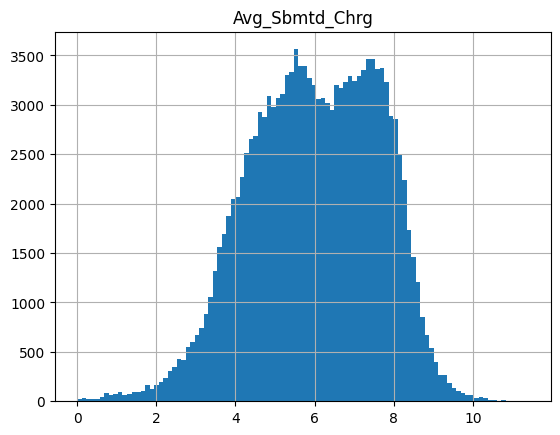

In [27]:
X.select("Avg_Sbmtd_Chrg").toPandas().hist(bins=100)